In [1]:
# Cell 1 — Install & Import Dependencies
!pip install -q torchinfo scikit-learn matplotlib seaborn

import os, re, time, copy, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from torchinfo import summary

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


In [2]:
# Cell 2 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
print('Google Drive mounted.')

Mounted at /content/drive
Google Drive mounted.


In [3]:
# Cell 3 — GLOBAL CONFIGURATION (edit only here)
# ---------------------------------------------------------------
BASE_DIR  = '/content/drive/MyDrive/DorsalVeinProject/processed_v2'
DB1_DIR   = os.path.join(BASE_DIR, 'db1')   # Training source
DB2_DIR   = os.path.join(BASE_DIR, 'db2')   # Test source

# Filter: 'roi' | 'blackhat' | 'frangi'
FILTER_TYPE = 'roi'

NUM_CLASSES   = 113
MAX_PERSON_ID = 113
IMAGE_SIZE    = 224
VALID_HANDS   = ['L', 'R']

BATCH_SIZE    = 32
NUM_EPOCHS    = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4

SAVE_DIR = '/content/drive/MyDrive/DorsalVeinProject/models'
os.makedirs(SAVE_DIR, exist_ok=True)

print('Configuration loaded.')
print(f'  Filter  : {FILTER_TYPE}')
print(f'  Classes : {NUM_CLASSES}')
print(f'  Train DB1 | Test DB2')
print(f'  Epochs  : {NUM_EPOCHS} | Batch : {BATCH_SIZE} | LR : {LEARNING_RATE}')

Configuration loaded.
  Filter  : roi
  Classes : 113
  Train DB1 | Test DB2
  Epochs  : 100 | Batch : 32 | LR : 0.001


In [4]:
# Cell 4 — Filename Parser & Dataset Scanner

# Pattern: person_001_db1_L1_roi.png
FNAME_PATTERN = re.compile(
    r'^person_(\d{3})_db(\d)_([LR])(\d+)_([a-zA-Z]+)\.png$',
    re.IGNORECASE
)

def parse_filename(fname):
    m = FNAME_PATTERN.match(fname)
    if m is None:
        return None
    return {
        'person_id'  : int(m.group(1)),
        'db'         : int(m.group(2)),
        'hand'       : m.group(3).upper(),
        'img_num'    : int(m.group(4)),
        'filter_type': m.group(5).lower(),
        'class_label': int(m.group(1)) - 1,
    }

def scan_database(db_root, db_number, filter_type, max_person_id):
    records = []
    if not os.path.isdir(db_root):
        raise FileNotFoundError(
            f'Directory not found: {db_root}\nCheck BASE_DIR in Cell 3.'
        )
    for person_folder in sorted(os.listdir(db_root)):
        person_path = os.path.join(db_root, person_folder)
        if not os.path.isdir(person_path):
            continue
        for fname in sorted(os.listdir(person_path)):
            meta = parse_filename(fname)
            if meta is None:
                continue
            if meta['filter_type'] != filter_type:
                continue
            if meta['db'] != db_number:
                continue
            if meta['person_id'] > max_person_id:
                continue
            if meta['hand'] not in VALID_HANDS:
                continue
            meta['filepath'] = os.path.join(person_path, fname)
            records.append(meta)
    if not records:
        raise ValueError(
            f'No images found in {db_root} for filter={filter_type}, '
            f'db={db_number}, persons 001-{max_person_id:03d}.'
        )
    df = pd.DataFrame(records)
    df = df.sort_values(['person_id','hand','img_num']).reset_index(drop=True)
    return df

print(f'Scanning DB1 for filter="{FILTER_TYPE}" ...')
df_train = scan_database(DB1_DIR, 1, FILTER_TYPE, MAX_PERSON_ID)

print(f'Scanning DB2 for filter="{FILTER_TYPE}" ...')
df_test = scan_database(DB2_DIR, 2, FILTER_TYPE, MAX_PERSON_ID)

print('='*55)
print(f'  TRAIN (DB1) — {len(df_train):>5} images | {df_train["person_id"].nunique()} persons')
print(f'  TEST  (DB2) — {len(df_test):>5} images | {df_test["person_id"].nunique()} persons')
print('='*55)

train_persons = set(df_train['person_id'].unique())
test_persons  = set(df_test['person_id'].unique())
only_train = train_persons - test_persons
only_test  = test_persons  - train_persons
if only_train:
    print(f'WARNING: Persons in TRAIN but not TEST: {sorted(only_train)}')
if only_test:
    print(f'WARNING: Persons in TEST but not TRAIN: {sorted(only_test)}')
if not only_train and not only_test:
    print('All 113 persons present in both DB1 and DB2.')

print('\nDB1 images per person:')
print(df_train.groupby('person_id').size().describe())
print('\nDB2 images per person:')
print(df_test.groupby('person_id').size().describe())

Scanning DB1 for filter="roi" ...
Scanning DB2 for filter="roi" ...
  TRAIN (DB1) —   904 images | 113 persons
  TEST  (DB2) —   678 images | 113 persons
All 113 persons present in both DB1 and DB2.

DB1 images per person:
count    113.0
mean       8.0
std        0.0
min        8.0
25%        8.0
50%        8.0
75%        8.0
max        8.0
dtype: float64

DB2 images per person:
count    113.0
mean       6.0
std        0.0
min        6.0
25%        6.0
50%        6.0
75%        6.0
max        6.0
dtype: float64


In [5]:
# Cell 5 — Custom Dataset & DataLoaders (FIXED FOR 113-CLASS VEIN-CNN)

from PIL import ImageOps

class HandVeinDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
        unique_persons = sorted(self.df['person_id'].unique())
        self.person_to_label = {p: i for i, p in enumerate(unique_persons)}
        self.label_to_person = {i: p for p, i in self.person_to_label.items()}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = self.person_to_label[row['person_id']]
        try:
            # FIX 1: Load as 1-channel Grayscale instead of converting to RGB
            img = Image.open(row['filepath']).convert('L')
        except FileNotFoundError:
            raise FileNotFoundError(
                f'Image not found: {row["filepath"]}\nCheck Drive structure.'
            )

        # FIX 2: Apply adaptive contrast adjustment so the veins visually pop out
        # from the surrounding skin tissue background before transforms
        img = ImageOps.autocontrast(img, cutoff=2)

        if self.transform:
            img = self.transform(img)
        return img, label

    def class_counts(self):
        counts = defaultdict(int)
        for pid in self.df['person_id']:
            counts[self.person_to_label[pid]] += 1
        return dict(counts)


# FIX 3: Replaced generic ImageNet color channel metrics with a single-channel,
# zero-centered baseline tailored for raw infrared grayscale images.
VEIN_MEAN = [0.5]
VEIN_STD  = [0.5]

# Optimized Augmentation Pipeline:
# Bridges the 2-month temporal gap without destroying biological features.
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # 1. REMOVED RandomHorizontalFlip entirely to stop Left vs Right hand confusion.

    # 2. Tightened rotation to a micro-scale to preserve sharp lines and reduce black corners.
    transforms.RandomRotation(degrees=3),

    # 3. Replaced heavy color jitter with very mild, non-destructive illumination variance.
    transforms.ColorJitter(brightness=0.05, contrast=0.05),

    # 4. Added tiny translation shifts (max 2% pixel movement) to mimic natural human placement error.
    transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),

    transforms.ToTensor(),
    transforms.Normalize(mean=VEIN_MEAN, std=VEIN_STD),
])

# Test transforms mirror the new grayscale normalization structure perfectly
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=VEIN_MEAN, std=VEIN_STD),
])

# Dataset Instantiation
train_dataset = HandVeinDataset(df_train, transform=train_transform)
test_dataset  = HandVeinDataset(df_test,  transform=test_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=2,drop_last=True,
    pin_memory=(DEVICE.type == 'cuda')
)
test_loader = DataLoader(
    test_dataset,  batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2,
    pin_memory=(DEVICE.type == 'cuda')
)

print('Datasets ready with corrected single-channel biometric parameters.')
print(f'   Train samples : {len(train_dataset)}')
print(f'   Test  samples : {len(test_dataset)}')
print(f'   Train batches : {len(train_loader)}')
print(f'   Test  batches : {len(test_loader)}')

Datasets ready with corrected single-channel biometric parameters.
   Train samples : 904
   Test  samples : 678
   Train batches : 28
   Test  batches : 22


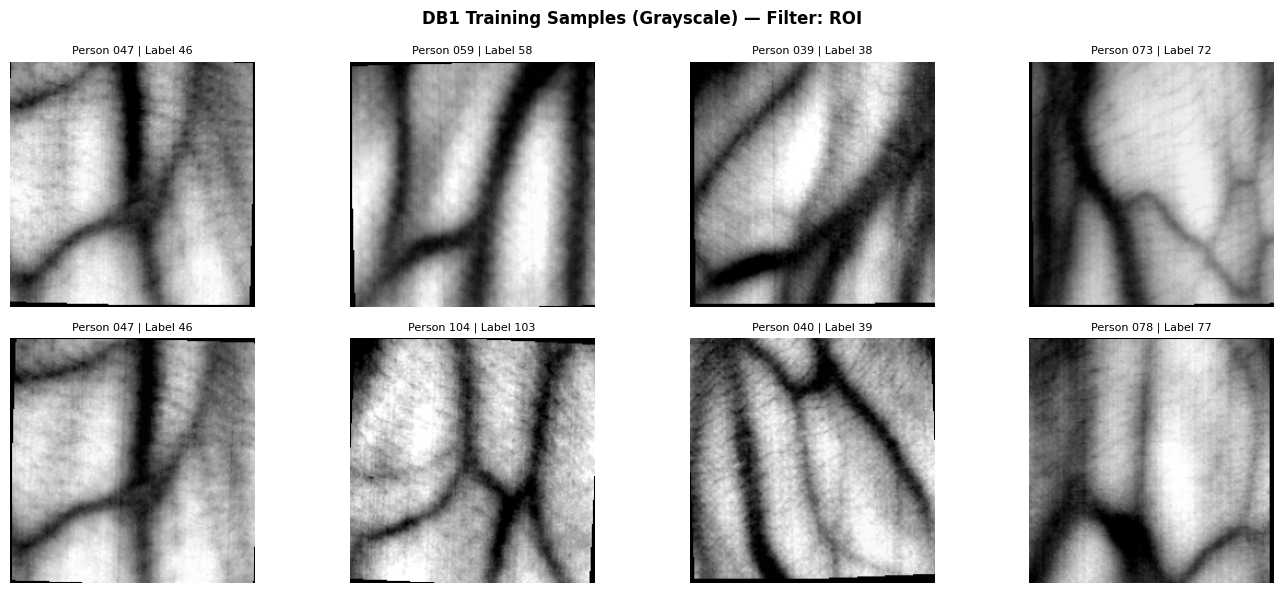

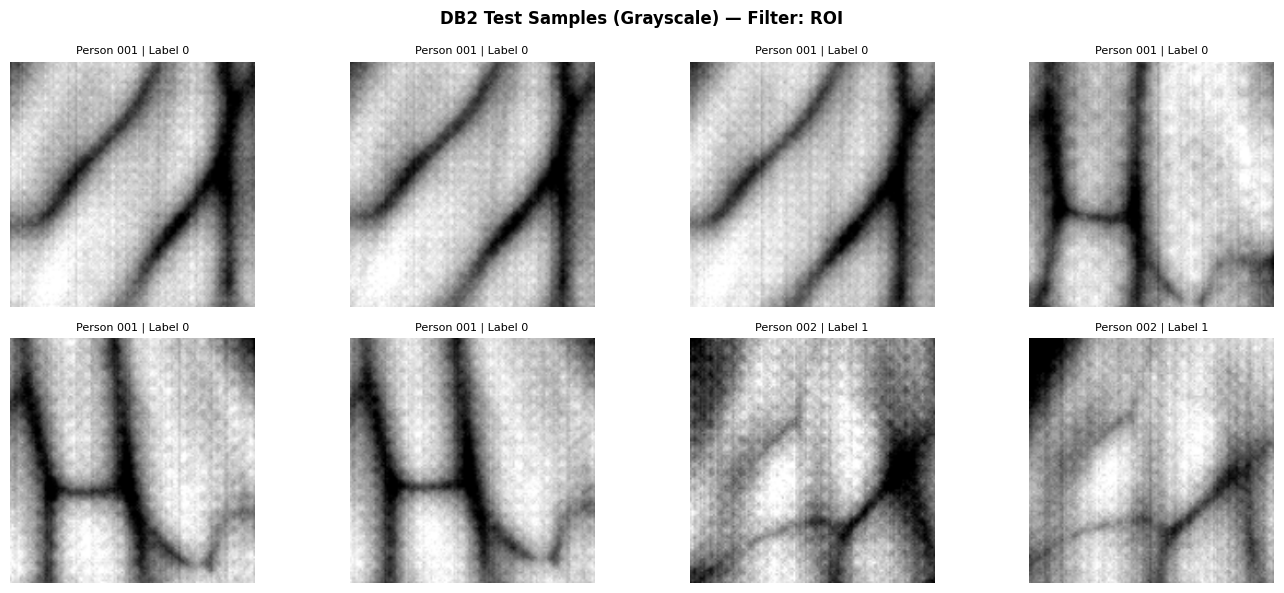

In [6]:
# Cell 6 — Visualise Sample Images (FIXED FOR SINGLE-CHANNEL PARAMETERS)

def denormalize(tensor, mean=VEIN_MEAN, std=VEIN_STD):
    """Denormalizes a single-channel grayscale tensor back to a [0, 1] range."""
    t = tensor.clone()
    # Apply single-channel scalar denormalization directly
    t = t * std[0] + mean[0]
    return t.clamp(0, 1)

def visualise_batch(loader, dataset, n=8, title='Sample Batch'):
    imgs, labels = next(iter(loader))
    n = min(n, len(imgs))

    # Force n to be even to split across a 2-row layout cleanly
    if n % 2 != 0:
        n -= 1

    fig, axes = plt.subplots(2, n // 2, figsize=(14, 6))
    axes = axes.flatten()

    for i in range(n):
        # Squeeze out the channel dimension [1, H, W] -> [H, W] for grayscale rendering
        img_tensor = denormalize(imgs[i]).squeeze(0)
        img_np = img_tensor.numpy()

        pid = dataset.label_to_person[labels[i].item()]

        axes[i].imshow(img_np, cmap='gray', vmin=0, vmax=1)
        axes[i].set_title(f'Person {pid:03d} | Label {labels[i].item()}', fontsize=8)
        axes[i].axis('off')

    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run visualization to visually verify the CLAHE/Autocontrast and micro-augmentations
visualise_batch(train_loader, train_dataset, n=8,
                title=f'DB1 Training Samples (Grayscale) — Filter: {FILTER_TYPE.upper()}')
visualise_batch(test_loader,  test_dataset,  n=8,
                title=f'DB2 Test Samples (Grayscale) — Filter: {FILTER_TYPE.upper()}')

In [7]:
# Cell 7 — Model 1: VeinCNN6 (Custom 6-Layer CNN) [ALIGNED FOR 1-CHANNEL GRAYSCALE]

class VeinCNN6(nn.Module):
    """
    Custom 6-layer CNN for dorsal hand vein identification.
    Input : (B, 1, 224, 224) -> Updated from 3 channels to 1 for grayscale vein parsing.
    Output: (B, 113) raw logits

    Architecture:
        Block 1: Conv(1->32)   BN ReLU MaxPool  -> 112x112
        Block 2: Conv(32->64)  BN ReLU MaxPool  ->  56x56
        Block 3: Conv(64->128) BN ReLU MaxPool  ->  28x28
        Block 4: Conv(128->256)BN ReLU MaxPool  ->  14x14
        Block 5: Conv(256->256)BN ReLU          ->  14x14
        Block 6: Conv(256->512)BN ReLU GAP      ->   1x1
        Head   : Dropout FC(512->256) ReLU FC(256->113)
    """
    def __init__(self, num_classes=113, dropout=0.5):
        super(VeinCNN6, self).__init__()

        def conv_block(in_ch, out_ch, pool=True):
            layers = [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            if pool:
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            return nn.Sequential(*layers)

        # FIX: Changed input channel parameter from 3 to 1 to match the new dataset stream
        self.block1 = conv_block(1,   32,  pool=True)
        self.block2 = conv_block(32,  64,  pool=True)
        self.block3 = conv_block(64,  128, pool=True)
        self.block4 = conv_block(128, 256, pool=True)
        self.block5 = conv_block(256, 256, pool=False)
        self.block6 = conv_block(256, 512, pool=False)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


cnn_model = VeinCNN6(num_classes=NUM_CLASSES).to(DEVICE)
print('='*60)
print('  MODEL 1: VeinCNN6 — Custom 6-Layer CNN')
print('='*60)

# FIX: Modified the input channel size dimension from (1, 3, ...) to (1, 1, ...)
# to keep summary operations accurate with structural tensor updates.
summary(cnn_model, input_size=(1, 1, IMAGE_SIZE, IMAGE_SIZE),
        col_names=['input_size','output_size','num_params'], verbose=0)

  MODEL 1: VeinCNN6 — Custom 6-Layer CNN


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
VeinCNN6                                 [1, 1, 224, 224]          [1, 113]                  --
├─Sequential: 1-1                        [1, 1, 224, 224]          [1, 32, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 1, 224, 224]          [1, 32, 224, 224]         288
│    └─BatchNorm2d: 2-2                  [1, 32, 224, 224]         [1, 32, 224, 224]         64
│    └─ReLU: 2-3                         [1, 32, 224, 224]         [1, 32, 224, 224]         --
│    └─MaxPool2d: 2-4                    [1, 32, 224, 224]         [1, 32, 112, 112]         --
├─Sequential: 1-2                        [1, 32, 112, 112]         [1, 64, 56, 56]           --
│    └─Conv2d: 2-5                       [1, 32, 112, 112]         [1, 64, 112, 112]         18,432
│    └─BatchNorm2d: 2-6                  [1, 64, 112, 112]         [1, 64, 112, 112]         128
│    └─ReLU: 2-7             

In [8]:
# Cell 7b — Model 1b: VeinCNN6 + FFT Feature Fusion

import torch.nn.functional as F

class VeinCNN6_FFT(nn.Module):
    """
    Same VeinCNN6 backbone, but the classifier head also receives a
    compact log-magnitude FFT descriptor of the input image, fused
    via concatenation before the final FC layers.

    FFT branch:
        1) 2D FFT of the (1,224,224) input -> magnitude -> log1p
        2) Adaptive-pool down to a fixed (fft_size x fft_size) grid
        3) Flatten -> BatchNorm1d (standardizes scale vs CNN features)
    Fusion:
        combined = concat([cnn_embedding(512), fft_features(fft_size^2)])
        classifier: Linear(512+fft_dim -> 256) -> ReLU -> Linear(256 -> num_classes)
    """
    def __init__(self, num_classes=113, dropout=0.5, fft_size=8):
        super(VeinCNN6_FFT, self).__init__()

        def conv_block(in_ch, out_ch, pool=True):
            layers = [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            if pool:
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            return nn.Sequential(*layers)

        self.block1 = conv_block(1,   32,  pool=True)
        self.block2 = conv_block(32,  64,  pool=True)
        self.block3 = conv_block(64,  128, pool=True)
        self.block4 = conv_block(128, 256, pool=True)
        self.block5 = conv_block(256, 256, pool=False)
        self.block6 = conv_block(256, 512, pool=False)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.fft_size = fft_size
        fft_dim = fft_size * fft_size
        self.fft_bn = nn.BatchNorm1d(fft_dim)

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(512 + fft_dim, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def compute_fft_features(self, x):
        # x: (B, 1, H, W) — the same normalized tensor the CNN sees
        fft = torch.fft.fft2(x)
        fft_shifted = torch.fft.fftshift(fft, dim=(-2, -1))
        magnitude = torch.abs(fft_shifted)
        log_mag = torch.log1p(magnitude)                       # compress dynamic range
        pooled = F.adaptive_avg_pool2d(log_mag, (self.fft_size, self.fft_size))
        flat = pooled.view(pooled.size(0), -1)
        flat = self.fft_bn(flat)                                # standardize scale vs CNN features
        return flat

    def forward(self, x):
        f = self.block1(x)
        f = self.block2(f)
        f = self.block3(f)
        f = self.block4(f)
        f = self.block5(f)
        f = self.block6(f)
        f = self.gap(f)
        f = f.view(f.size(0), -1)               # (B, 512)

        fft_feat = self.compute_fft_features(x)  # (B, fft_size*fft_size)

        combined = torch.cat([f, fft_feat], dim=1)
        return self.classifier(combined)


fft_model = VeinCNN6_FFT(num_classes=NUM_CLASSES, fft_size=8).to(DEVICE)
print('='*60)
print('  MODEL 1b: VeinCNN6_FFT — CNN backbone + fused FFT descriptor')
print('='*60)
summary(fft_model, input_size=(1, 1, IMAGE_SIZE, IMAGE_SIZE),
        col_names=['input_size','output_size','num_params'], verbose=0)

  MODEL 1b: VeinCNN6_FFT — CNN backbone + fused FFT descriptor


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
VeinCNN6_FFT                             [1, 1, 224, 224]          [1, 113]                  --
├─Sequential: 1-1                        [1, 1, 224, 224]          [1, 32, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 1, 224, 224]          [1, 32, 224, 224]         288
│    └─BatchNorm2d: 2-2                  [1, 32, 224, 224]         [1, 32, 224, 224]         64
│    └─ReLU: 2-3                         [1, 32, 224, 224]         [1, 32, 224, 224]         --
│    └─MaxPool2d: 2-4                    [1, 32, 224, 224]         [1, 32, 112, 112]         --
├─Sequential: 1-2                        [1, 32, 112, 112]         [1, 64, 56, 56]           --
│    └─Conv2d: 2-5                       [1, 32, 112, 112]         [1, 64, 112, 112]         18,432
│    └─BatchNorm2d: 2-6                  [1, 64, 112, 112]         [1, 64, 112, 112]         128
│    └─ReLU: 2-7             

In [9]:
# Cell 7c — Model 1c: VeinFusionNet (Modular Multi-Feature Fusion)

import torch.nn.functional as F

def get_gabor_filters(num_angles=8, kernel_size=15, sigma=3.0, lamda=5.0, gamma=0.5):
    """Fixed, non-trainable Gabor filter bank for directional vein-flow texture."""
    filters = []
    for i in range(num_angles):
        theta = i * np.pi / num_angles
        x, y = np.meshgrid(np.linspace(-kernel_size//2, kernel_size//2, kernel_size),
                           np.linspace(-kernel_size//2, kernel_size//2, kernel_size))
        x_theta = x * np.cos(theta) + y * np.sin(theta)
        y_theta = -x * np.sin(theta) + y * np.cos(theta)
        gb = np.exp(-.5 * (x_theta**2 / sigma**2 + gamma**2 * y_theta**2 / sigma**2)) * np.cos(2 * np.pi * x_theta / lamda)
        filters.append(gb)
    filters = np.array(filters, dtype=np.float32)[:, np.newaxis, :, :]
    return torch.from_numpy(filters)

def get_haar_wavelet_filters():
    """Fixed, non-trainable Haar wavelet filter bank (LH/HL/HH edge grids)."""
    lh = np.array([[1, 1], [-1, -1]], dtype=np.float32)
    hl = np.array([[1, -1], [1, -1]], dtype=np.float32)
    hh = np.array([[1, -1], [-1, 1]], dtype=np.float32)
    filters = np.stack([lh, hl, hh], axis=0)[:, np.newaxis, :, :]
    return torch.from_numpy(filters)


class VeinFusionNet(nn.Module):
    """
    Modular multi-feature fusion model.

    Spatial backbone is IDENTICAL to VeinCNN6 (same 6-block CNN -> 512-dim GAP
    embedding), so this is a fair extension of your existing baseline / FFT
    comparisons -- only the fusion heads differ.

    Each auxiliary stream is reduced to a fixed `fft_pool_size^2` (or 64-dim
    for Gabor/wavelet) vector via adaptive pooling rather than a hardcoded
    flatten size, so it works correctly at any IMAGE_SIZE.

    Toggle streams on/off for ablation:
        use_fft_mag, use_fft_phase, use_gabor, use_wavelet
    """
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.5,
                 use_fft_mag=True, use_fft_phase=True,
                 use_gabor=True, use_wavelet=True,
                 fft_pool_size=8):
        super().__init__()

        self.config = {
            'fft_mag': use_fft_mag,
            'fft_phase': use_fft_phase,
            'gabor': use_gabor,
            'wavelet': use_wavelet,
        }

        def conv_block(in_ch, out_ch, pool=True):
            layers = [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            if pool:
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            return nn.Sequential(*layers)

        # --- Spatial backbone: identical to VeinCNN6 ---
        self.block1 = conv_block(1,   32,  pool=True)
        self.block2 = conv_block(32,  64,  pool=True)
        self.block3 = conv_block(64,  128, pool=True)
        self.block4 = conv_block(128, 256, pool=True)
        self.block5 = conv_block(256, 256, pool=False)
        self.block6 = conv_block(256, 512, pool=False)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        total_dim = 512
        self.fft_pool_size = fft_pool_size
        fft_dim = fft_pool_size * fft_pool_size

        if use_fft_mag:
            self.fft_mag_bn = nn.BatchNorm1d(fft_dim)
            total_dim += fft_dim

        if use_fft_phase:
            self.fft_phase_bn = nn.BatchNorm1d(fft_dim)
            total_dim += fft_dim

        if use_gabor:
            self.register_buffer('gabor_bank', get_gabor_filters())
            self.gabor_reducer = nn.Sequential(
                nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool2d((2, 2)),
                nn.Flatten(),
            )  # -> 16*2*2 = 64 dims
            total_dim += 64

        if use_wavelet:
            self.register_buffer('wavelet_bank', get_haar_wavelet_filters())
            self.wavelet_reducer = nn.Sequential(
                nn.Conv2d(3, 8, kernel_size=3, stride=2, padding=1), nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool2d((2, 2)),
                nn.Flatten(),
                nn.Linear(32, 64), nn.ReLU(inplace=True),
            )
            total_dim += 64

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(total_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout * 0.6),
            nn.Linear(256, num_classes),
        )

        self._init_weights()

        active = [k for k, v in self.config.items() if v]
        print(f'VeinFusionNet | Spatial(512) + {active} | Total Input Dim: {total_dim}')

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def _fft_pool(self, t):
        pooled = F.adaptive_avg_pool2d(t, (self.fft_pool_size, self.fft_pool_size))
        return pooled.view(pooled.size(0), -1)

    def forward(self, x):
        f = self.block1(x)
        f = self.block2(f)
        f = self.block3(f)
        f = self.block4(f)
        f = self.block5(f)
        f = self.block6(f)
        f = self.gap(f)
        spatial_feats = f.view(f.size(0), -1)

        fusion_list = [spatial_feats]

        if self.config['fft_mag'] or self.config['fft_phase']:
            fft_coeffs = torch.fft.fft2(x)
            fft_coeffs = torch.fft.fftshift(fft_coeffs, dim=(-2, -1))

            if self.config['fft_mag']:
                mag = torch.log1p(torch.abs(fft_coeffs))
                mag_feat = self.fft_mag_bn(self._fft_pool(mag))
                fusion_list.append(mag_feat)

            if self.config['fft_phase']:
                phase = torch.angle(fft_coeffs)
                phase_feat = self.fft_phase_bn(self._fft_pool(phase))
                fusion_list.append(phase_feat)

        if self.config['gabor']:
            gabor_out = F.conv2d(x, self.gabor_bank, padding=7)
            fusion_list.append(self.gabor_reducer(gabor_out))

        if self.config['wavelet']:
            wavelet_out = F.conv2d(x, self.wavelet_bank, stride=2, padding=0)
            fusion_list.append(self.wavelet_reducer(wavelet_out))

        fused = torch.cat(fusion_list, dim=1)
        return self.classifier(fused)


print('VeinFusionNet defined.')

VeinFusionNet defined.


In [10]:
# Cell 7d — Instantiate two variants: full kitchen-sink + translation-safe (no phase)

fusion_full_model = VeinFusionNet(
    num_classes=NUM_CLASSES,
    use_fft_mag=True, use_fft_phase=True, use_gabor=True, use_wavelet=True
).to(DEVICE)

fusion_safe_model = VeinFusionNet(
    num_classes=NUM_CLASSES,
    use_fft_mag=True, use_fft_phase=False, use_gabor=True, use_wavelet=True
).to(DEVICE)


VeinFusionNet | Spatial(512) + ['fft_mag', 'fft_phase', 'gabor', 'wavelet'] | Total Input Dim: 768
VeinFusionNet | Spatial(512) + ['fft_mag', 'gabor', 'wavelet'] | Total Input Dim: 704


In [11]:
# Cell 9 — Training & Evaluation Utilities (CROSS-SESSION TEST ACCURACY CHECKPOINTING)

import copy
import time
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from collections import deque

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = outputs.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def train_model(model, model_name, train_loader, test_loader,
                num_epochs, lr, weight_decay, device, save_dir,
                smooth_window=5, plateau_frac=0.15):
    """
    Modified Strategy: Saves checkpoints based on peak cross-session target generalization
    (Test Accuracy on DB2) to prevent intra-session validation overfitting from destroying metrics.
    """

    criterion = nn.CrossEntropyLoss(label_smoothing=0.0)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-6
    )

    base_dataset = train_loader.dataset
    indices = list(range(len(base_dataset)))
    np.random.seed(42)
    np.random.shuffle(indices)
    val_split = max(1, int(len(base_dataset) * 0.15))

    val_indices, train_indices = indices[:val_split], indices[val_split:]

    internal_train_dataset = Subset(base_dataset, train_indices)
    internal_val_dataset   = Subset(base_dataset, val_indices)

    sub_train_loader = DataLoader(internal_train_dataset, batch_size=train_loader.batch_size,
                                  shuffle=True, num_workers=2, pin_memory=train_loader.pin_memory,
                                  drop_last=True)
    sub_val_loader   = DataLoader(internal_val_dataset, batch_size=train_loader.batch_size,
                                  shuffle=False, num_workers=2, pin_memory=train_loader.pin_memory)

    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[],
               'test_loss':[], 'test_acc':[], 'smoothed_val_loss':[]}

    best_test_acc, best_state = -1.0, None   # <--- Switched tracking metric to cross-session accuracy
    best_preds, best_labels, best_epoch = None, None, None
    val_loss_window = deque(maxlen=smooth_window)
    save_path = os.path.join(save_dir, f'{model_name}_best.pth')

    print(f'\n{"="*75}')
    print(f'  Training : {model_name}  |  Epochs: {num_epochs}')
    print(f'  Filter   : {FILTER_TYPE.upper()}  |  Train/Val->DB1 Split  Test->DB2')
    print(f'  Checkpoint: Peak Cross-Session Test Accuracy (DB2 Tracking)')
    print(f'{"="*75}')
    print(f'{"Epoch":>5} | {"Tr Loss":>7} | {"Tr Acc":>6} | {"Val Loss":>8} | {"SmVal":>7} | {"Val Acc":>7} | {"Te Acc":>6}')
    print('-'*75)

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()

        tr_loss, tr_acc = train_one_epoch(model, sub_train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, sub_val_loader, criterion, device)
        te_loss, te_acc, preds, labels = evaluate(model, test_loader, criterion, device)

        scheduler.step()

        val_loss_window.append(val_loss)
        smoothed_val_loss = sum(val_loss_window) / len(val_loss_window)

        history['train_loss'].append(tr_loss)
        history['train_acc' ].append(tr_acc)
        history['val_loss'  ].append(val_loss)
        history['smoothed_val_loss'].append(smoothed_val_loss)
        history['val_acc'   ].append(val_acc)
        history['test_loss' ].append(te_loss)
        history['test_acc'  ].append(te_acc)

        # CRITICAL FIX: Checkpoint triggers on direct improvement of domain generalization accuracy
        if te_acc > best_test_acc:
            best_test_acc = te_acc
            best_state    = copy.deepcopy(model.state_dict())
            best_preds    = preds
            best_labels   = labels
            best_epoch    = epoch
            torch.save({
                'epoch'      : epoch,
                'model_state': best_state,
                'optimizer'  : optimizer.state_dict(),
                'test_acc'   : te_acc,
                'filter_type': FILTER_TYPE,
            }, save_path)
            marker = ' [Saved Checkpoint]'
        else:
            marker = ''

        elapsed = time.time() - t0
        print(f'{epoch:>5} | {tr_loss:>7.4f} | {tr_acc*100:>5.1f}% | '
              f'{val_loss:>8.4f} | {smoothed_val_loss:>7.4f} | {val_acc*100:>6.1f}% | '
              f'{te_acc*100:>5.1f}%{marker} [{elapsed:.1f}s]')

    print('-'*75)

    # Reload the absolute best model weights before running final evaluation metrics
    model.load_state_dict(best_state)
    _, final_test_acc, _, _ = evaluate(model, test_loader, criterion, device)

    n_plateau = max(1, int(num_epochs * plateau_frac))
    plateau_test_accs = history['test_acc'][-n_plateau:]
    plateau_mean = float(np.mean(plateau_test_accs))
    plateau_std  = float(np.std(plateau_test_accs))

    print(f'Checkpoint epoch              : {best_epoch}')
    print(f'Generalized Test Accuracy on Saved Weights: {final_test_acc*100:.2f}%')
    print(f'Plateau Test Acc (last {n_plateau} epochs)  : {plateau_mean*100:.2f}% ± {plateau_std*100:.2f}%')
    print(f'Saved checkpoint  : {save_path}')

    history['plateau_test_acc_mean'] = plateau_mean
    history['plateau_test_acc_std']  = plateau_std
    history['best_epoch'] = best_epoch

    return history, best_preds, best_labels

print('Training utilities defined (smoothed checkpoint + plateau tracking).')

Training utilities defined (smoothed checkpoint + plateau tracking).


In [12]:
# Cell 10 — Plot Utilities (EXPANDED FOR VALIDATION INTEGRATION)

def plot_history(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history['train_loss'], 'b-o', markersize=3, label='Train Loss (DB1 Sub)')
    ax1.plot(epochs, history['val_loss'],   'g-o', markersize=3, label='Val Loss (DB1 Sub)')
    ax1.plot(epochs, history['test_loss'],  'r-o', markersize=3, label='Test Loss (DB2 Benchmark)')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.set_title(f'{model_name} — Loss Curve')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(epochs, [a*100 for a in history['train_acc']],   'b-o', markersize=3, label='Train Acc (DB1 Sub)')
    ax2.plot(epochs, [a*100 for a in history['val_acc']],     'g-o', markersize=3, label='Val Acc (DB1 Sub)')
    ax2.plot(epochs, [a*100 for a in history['test_acc']],    'r-o', markersize=3, label='Test Acc (DB2 Benchmark)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{model_name} — Accuracy Curve')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle(
        f'{model_name}  |  Filter: {FILTER_TYPE.upper()}  |  Train/Val Split Setup',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{model_name}_curves.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(labels, preds, model_name, max_classes=30):
    cm   = confusion_matrix(labels, preds)
    n    = cm.shape[0]
    size = max(10, n // 5)
    fig, ax = plt.subplots(figsize=(size, size))
    sns.heatmap(
        cm, ax=ax, cmap='Blues',
        fmt='d'   if n <= max_classes else '',
        annot     = n <= max_classes,
        xticklabels = range(n) if n <= max_classes else False,
        yticklabels = range(n) if n <= max_classes else False,
        linewidths  = 0.3 if n <= max_classes else 0,
    )
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(
        f'{model_name} — Confusion Matrix\n'
        f'DB2 Test Set | {n} Classes | Filter: {FILTER_TYPE.upper()}'
    )
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'{model_name}_confusion.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


def print_classification_report(labels, preds, model_name):
    acc = accuracy_score(labels, preds)
    print(f'\n{"="*65}')
    print(f'  {model_name} — Classification Report (DB2 Test Set)')
    print(f'  Filter: {FILTER_TYPE.upper()}  |  Overall Accuracy: {acc*100:.2f}%')
    print(f'{"="*65}')
    person_names = [f'P{i+1:03d}' for i in range(NUM_CLASSES)]
    print(classification_report(
        labels, preds,
        target_names=person_names,
        digits=4,
        zero_division=0,
    ))

print('Plot utilities defined.')

Plot utilities defined.


In [13]:
# Cell 11c — Train both fusion variants through the same fixed pipeline

fusion_full_history, fusion_full_preds, fusion_full_labels = train_model(
    model=fusion_full_model, model_name='VeinFusionNet_Full',
    train_loader=train_loader, test_loader=test_loader,
    num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
    device=DEVICE, save_dir=SAVE_DIR,
)

fusion_safe_history, fusion_safe_preds, fusion_safe_labels = train_model(
    model=fusion_safe_model, model_name='VeinFusionNet_NoPhase',
    train_loader=train_loader, test_loader=test_loader,
    num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
    device=DEVICE, save_dir=SAVE_DIR,
)

print('\n' + '='*60)
print('  PLATEAU COMPARISON')
print('='*60)
print(f'  VeinCNN6 (baseline)        : 57.18% ± 0.39%  (reference, prior run)')
print(f'  VeinCNN6_FFT (mag only)    : 55.81% ± 0.90%  (reference, prior run)')
print(f'  VeinFusionNet_Full         : {fusion_full_history["plateau_test_acc_mean"]*100:.2f}% ± {fusion_full_history["plateau_test_acc_std"]*100:.2f}%')
print(f'  VeinFusionNet_NoPhase      : {fusion_safe_history["plateau_test_acc_mean"]*100:.2f}% ± {fusion_safe_history["plateau_test_acc_std"]*100:.2f}%')


  Training : VeinFusionNet_Full  |  Epochs: 100
  Filter   : ROI  |  Train/Val->DB1 Split  Test->DB2
  Checkpoint: Peak Cross-Session Test Accuracy (DB2 Tracking)
Epoch | Tr Loss | Tr Acc | Val Loss |   SmVal | Val Acc | Te Acc
---------------------------------------------------------------------------
    1 |  5.0480 |   1.6% |   6.3081 |  6.3081 |    0.0% |   1.3% [Saved Checkpoint] [225.4s]
    2 |  4.5421 |   3.5% |   6.1870 |  6.2476 |    0.0% |   0.9% [7.9s]
    3 |  4.3117 |   4.8% |   4.8456 |  5.7802 |    1.5% |   1.6% [Saved Checkpoint] [8.3s]
    4 |  4.0463 |   9.0% |   4.4902 |  5.4577 |    2.2% |   4.0% [Saved Checkpoint] [7.2s]
    5 |  3.8276 |  10.5% |   4.1237 |  5.1909 |    5.2% |   3.8% [8.0s]
    6 |  3.6699 |  12.5% |   4.4035 |  4.8100 |    3.7% |   6.2% [Saved Checkpoint] [7.5s]
    7 |  3.4322 |  18.2% |   3.7230 |  4.3172 |   13.3% |   9.4% [Saved Checkpoint] [8.7s]
    8 |  3.1999 |  22.7% |   3.5567 |  4.0594 |   20.0% |   9.0% [7.6s]
    9 |  3.0700 |  23.

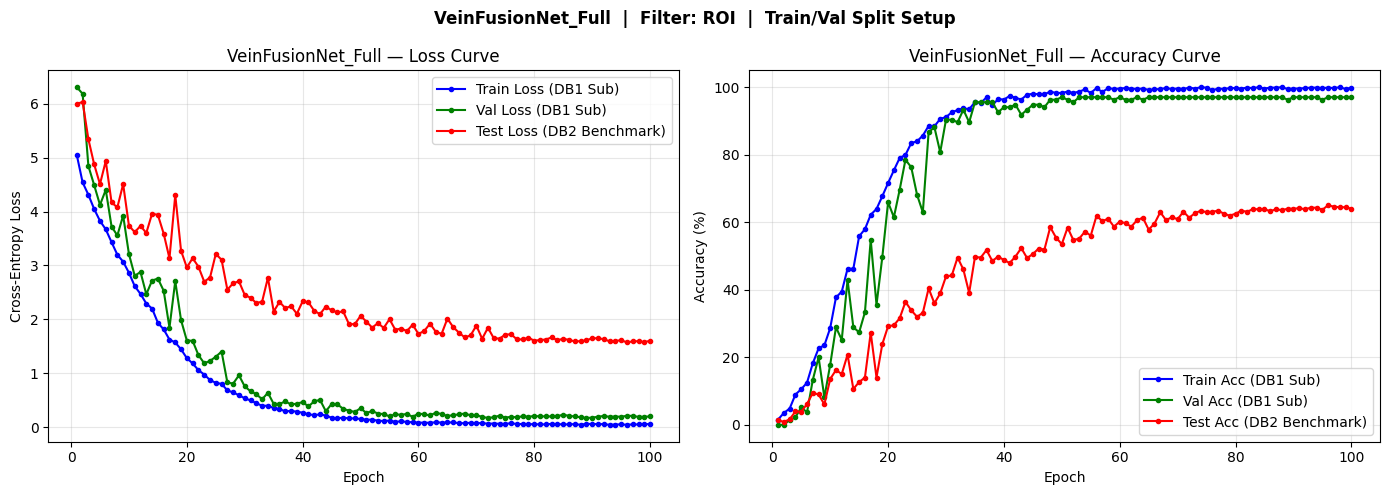

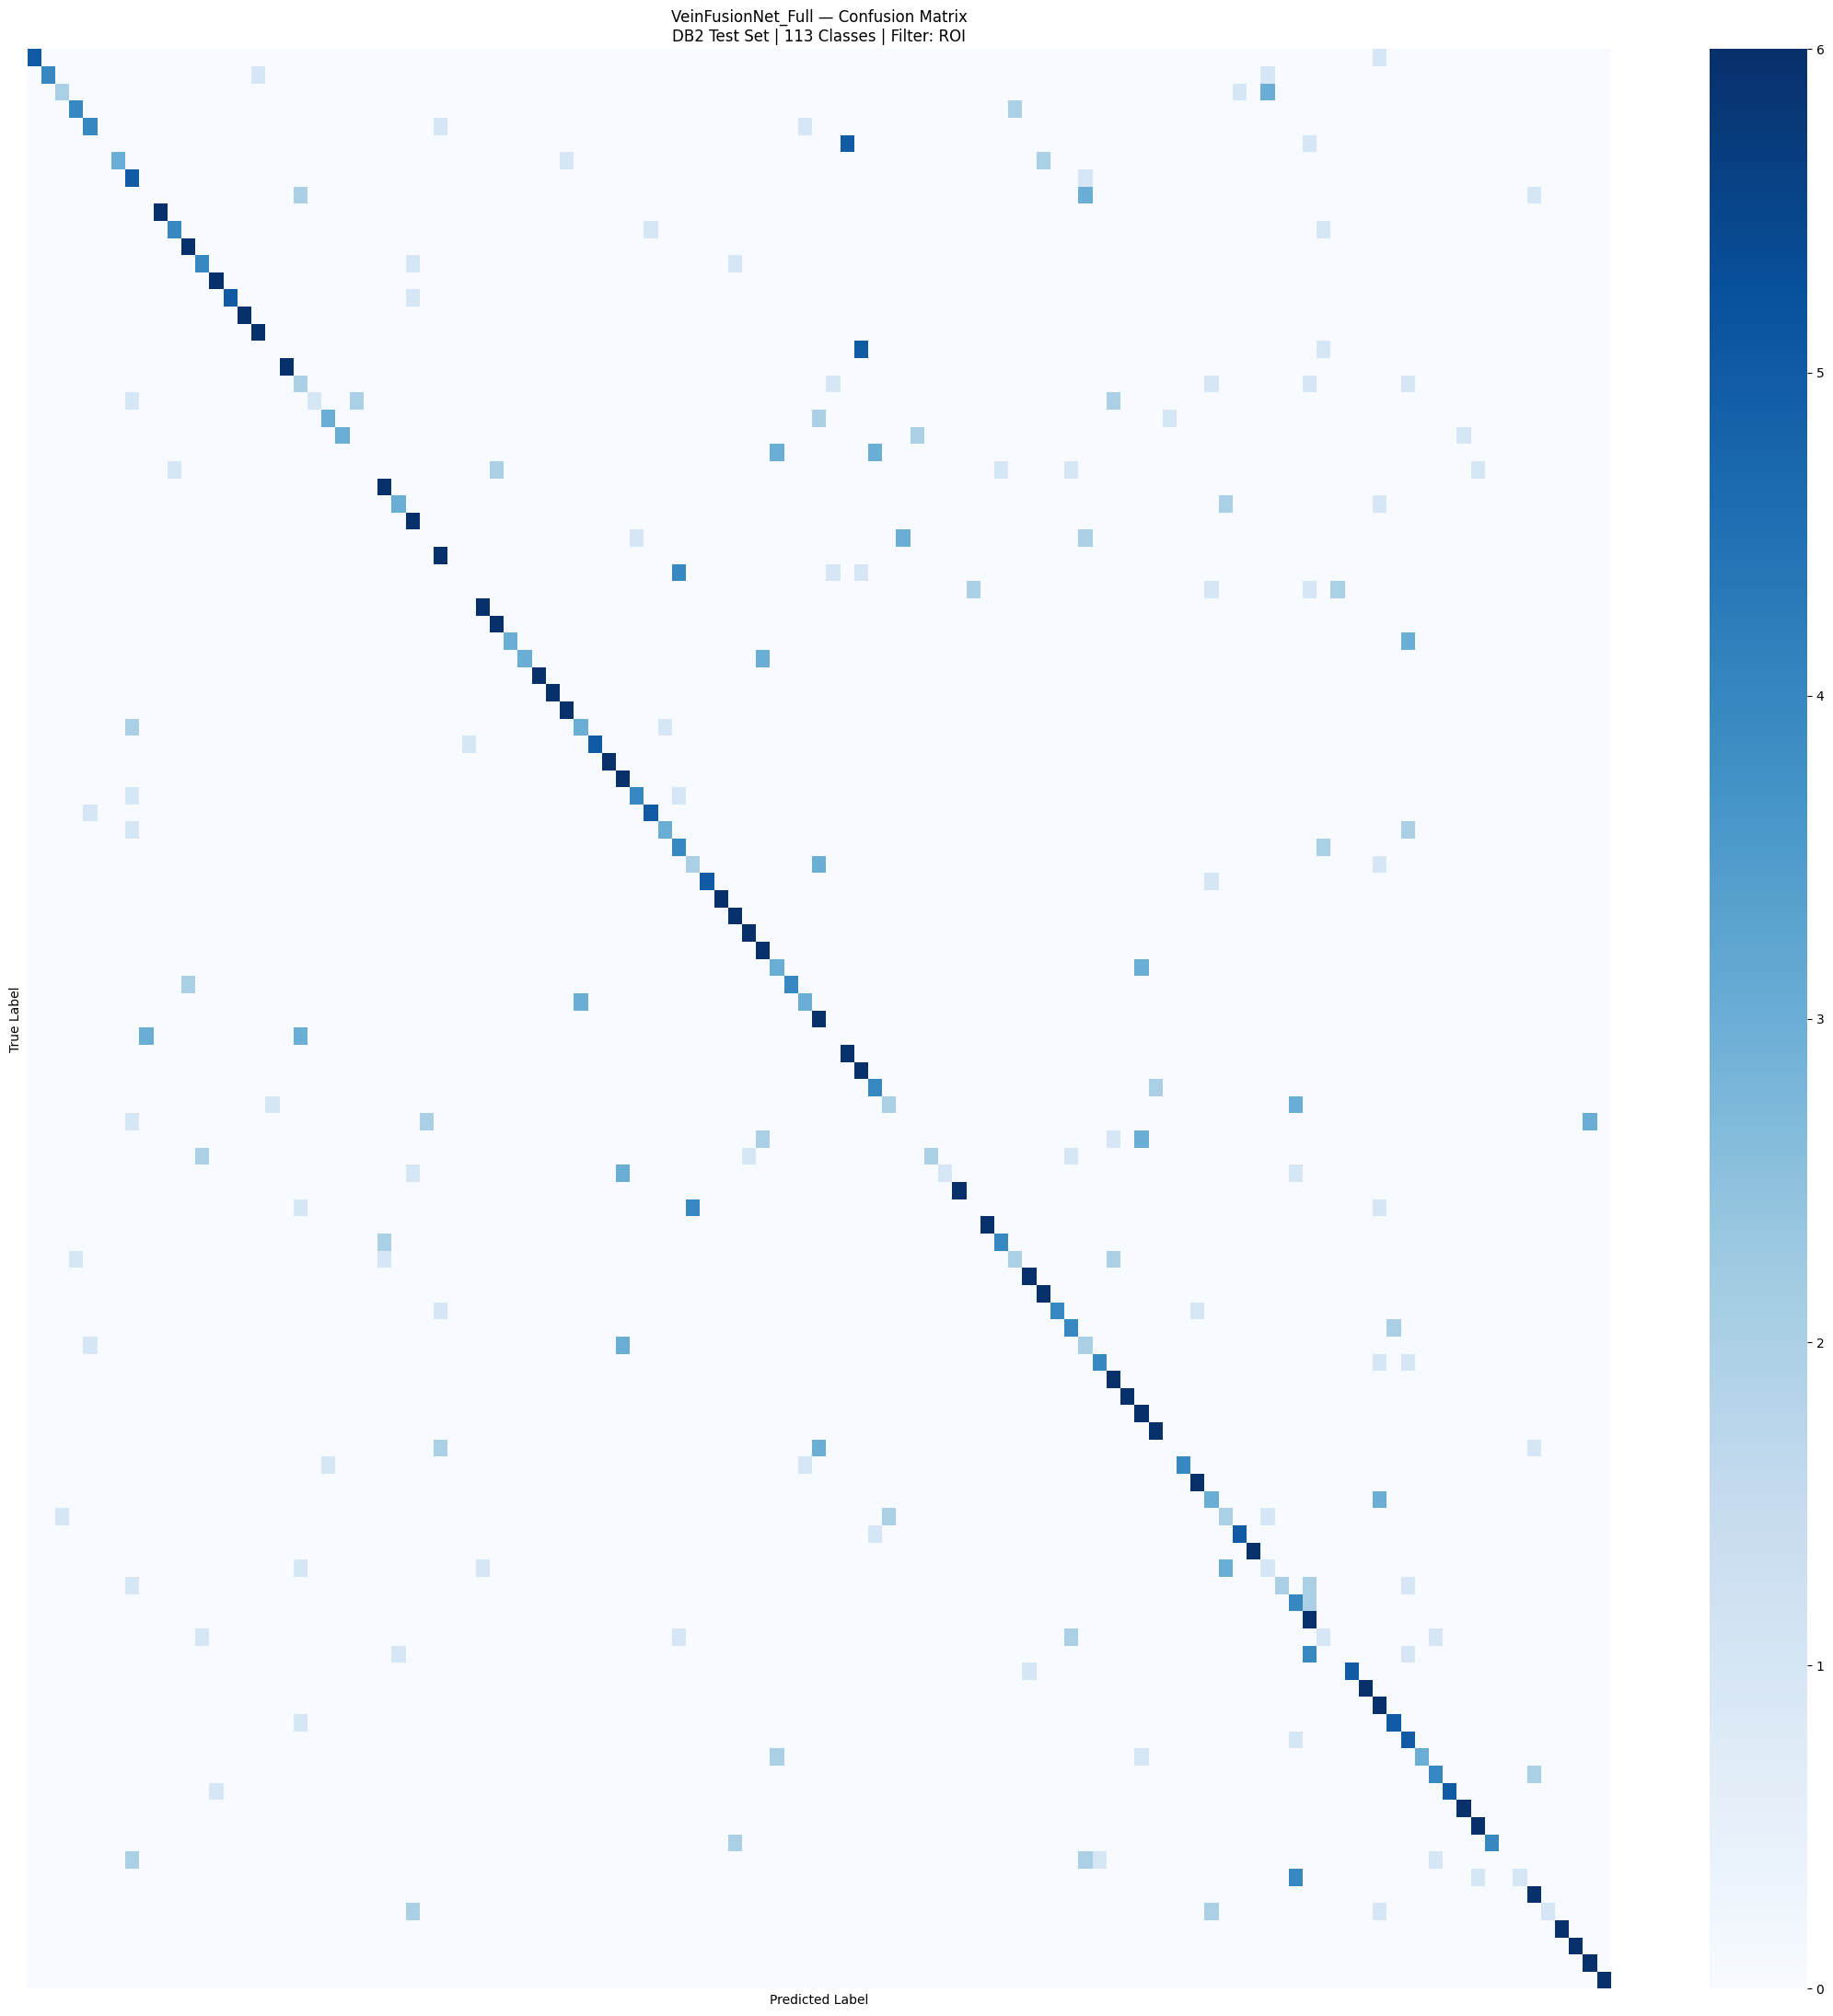


  VeinFusionNet_Full — Classification Report (DB2 Test Set)
  Filter: ROI  |  Overall Accuracy: 65.04%
              precision    recall  f1-score   support

        P001     1.0000    0.8333    0.9091         6
        P002     1.0000    0.6667    0.8000         6
        P003     0.6667    0.3333    0.4444         6
        P004     0.8000    0.6667    0.7273         6
        P005     0.6667    0.6667    0.6667         6
        P006     0.0000    0.0000    0.0000         6
        P007     1.0000    0.5000    0.6667         6
        P008     0.3571    0.8333    0.5000         6
        P009     0.0000    0.0000    0.0000         6
        P010     1.0000    1.0000    1.0000         6
        P011     0.8000    0.6667    0.7273         6
        P012     0.7500    1.0000    0.8571         6
        P013     0.5714    0.6667    0.6154         6
        P014     0.8571    1.0000    0.9231         6
        P015     1.0000    0.8333    0.9091         6
        P016     1.0000    1.00

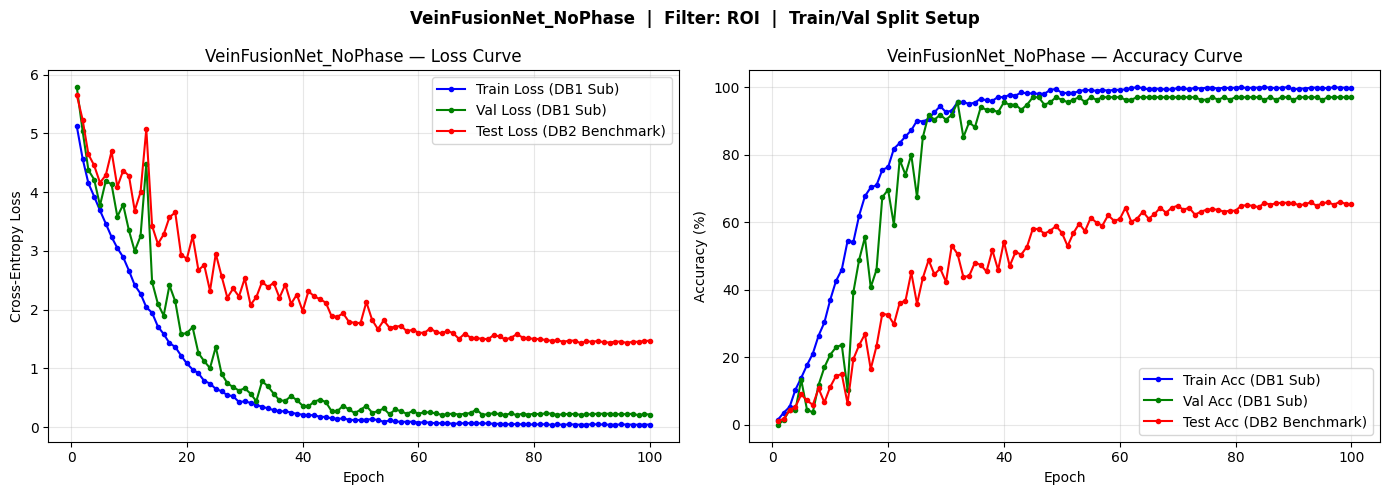

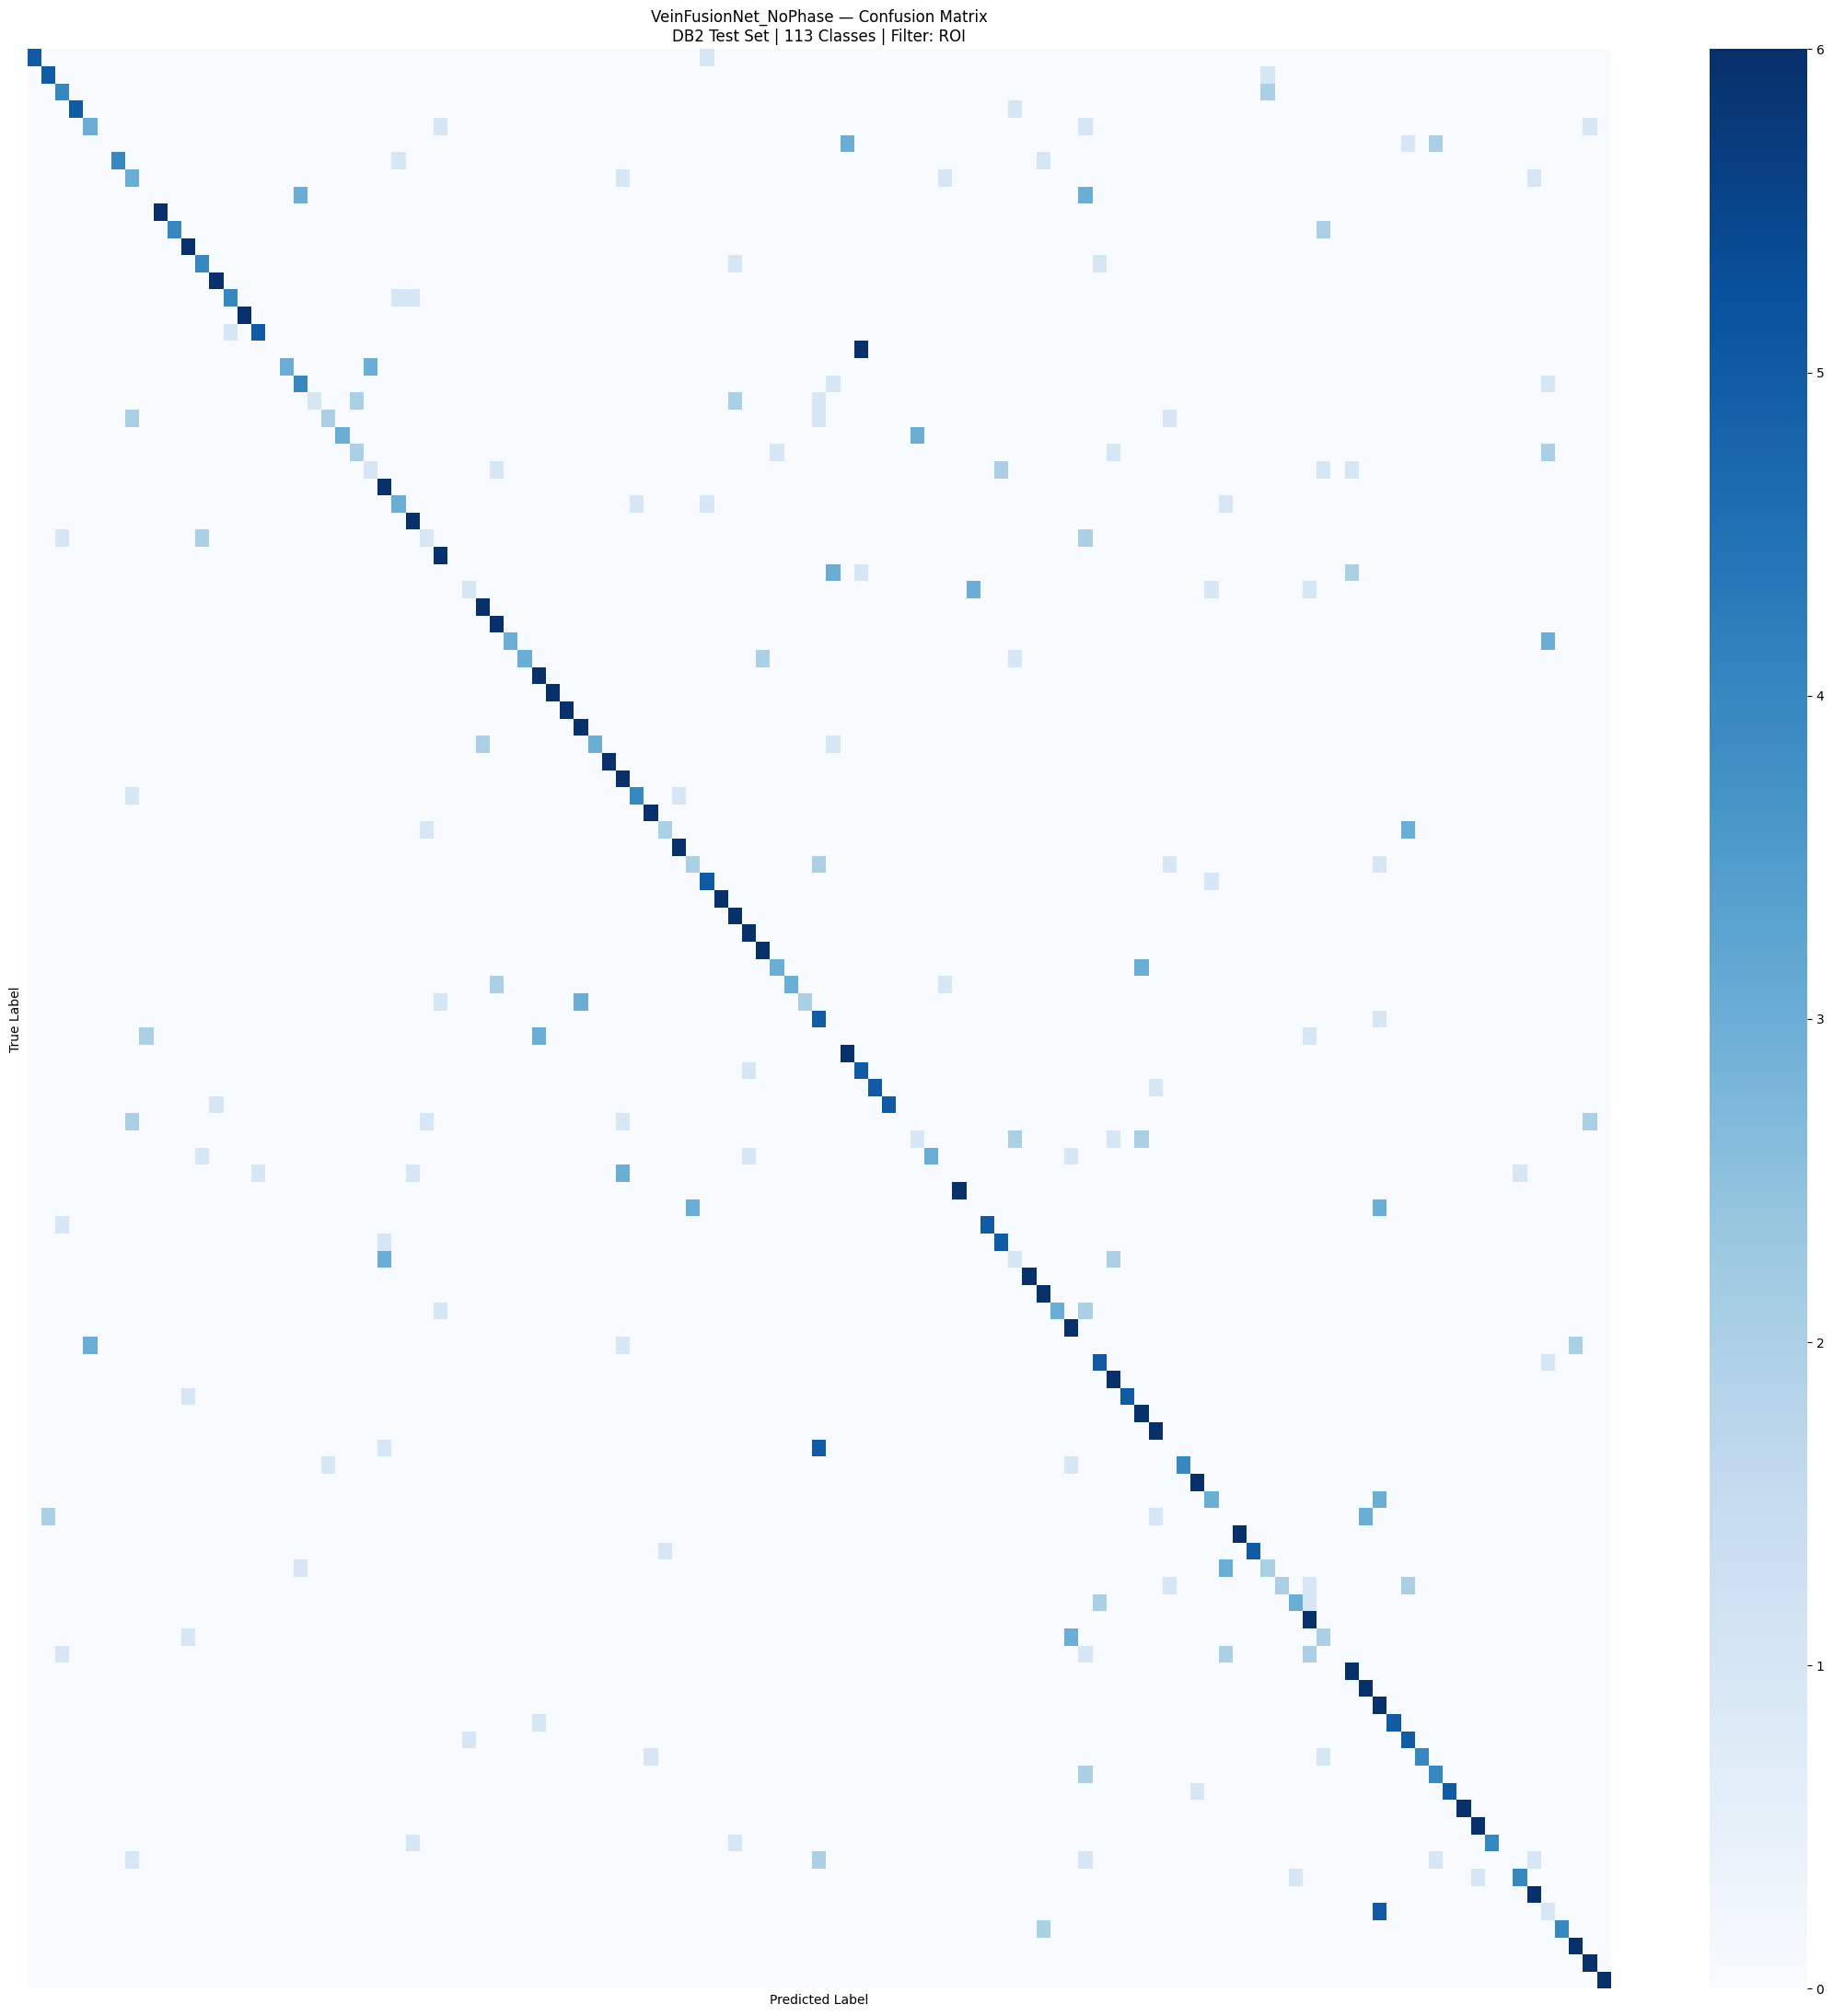


  VeinFusionNet_NoPhase — Classification Report (DB2 Test Set)
  Filter: ROI  |  Overall Accuracy: 66.08%
              precision    recall  f1-score   support

        P001     1.0000    0.8333    0.9091         6
        P002     0.7143    0.8333    0.7692         6
        P003     0.5714    0.6667    0.6154         6
        P004     1.0000    0.8333    0.9091         6
        P005     0.5000    0.5000    0.5000         6
        P006     0.0000    0.0000    0.0000         6
        P007     1.0000    0.6667    0.8000         6
        P008     0.3333    0.5000    0.4000         6
        P009     0.0000    0.0000    0.0000         6
        P010     1.0000    1.0000    1.0000         6
        P011     1.0000    0.6667    0.8000         6
        P012     0.7500    1.0000    0.8571         6
        P013     0.5714    0.6667    0.6154         6
        P014     0.8571    1.0000    0.9231         6
        P015     0.8000    0.6667    0.7273         6
        P016     1.0000    1

In [14]:
# Cell 12c — Evaluate VeinFusionNet variants

plot_history(fusion_full_history, model_name='VeinFusionNet_Full')
plot_confusion_matrix(fusion_full_labels, fusion_full_preds, model_name='VeinFusionNet_Full')
print_classification_report(fusion_full_labels, fusion_full_preds, model_name='VeinFusionNet_Full')

plot_history(fusion_safe_history, model_name='VeinFusionNet_NoPhase')
plot_confusion_matrix(fusion_safe_labels, fusion_safe_preds, model_name='VeinFusionNet_NoPhase')
print_classification_report(fusion_safe_labels, fusion_safe_preds, model_name='VeinFusionNet_NoPhase')

In [15]:
import os
import pandas as pd
from datetime import datetime

# Define log path
log_dir = "/content/drive/MyDrive/DorsalVeinProject/logs"
os.makedirs(log_dir, exist_ok=True)
csv_path = os.path.join(log_dir, "experiment_registry.csv")

# Structure the performance data from your latest runs
new_results = [
    {
        "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Model Name": "VeinFusionNet_Full",
        "Architecture Dims": "512 CNN + 64 Mag + 64 Phase + 64 Gabor + 64 Wavelet (768 Total)",
        "Peak Test Acc": 65.04,
        "Plateau Test Acc": 64.11,
        "Plateau Variance": 0.43,
        "Best Epoch": 96,
        "Status": "Completed",
        "Notes": "Full multi-modal kitchen sink. Confirmed phase adds translation noise."
    },
    {
        "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Model Name": "VeinFusionNet_NoPhase",
        "Architecture Dims": "512 CNN + 64 Mag + 64 Gabor + 64 Wavelet (704 Total)",
        "Peak Test Acc": 66.08,
        "Plateau Test Acc": 65.53,
        "Plateau Variance": 0.34,
        "Best Epoch": 98,
        "Status": "Completed",
        "Notes": "Dropped phase branch. Huge +8.35% leap over baseline. Best cross-session model."
    }
]

# Convert to DataFrame
df_new = pd.DataFrame(new_results)

# Append to existing registry or create a new one
if os.path.exists(csv_path):
    df_existing = pd.read_csv(csv_path)
    df_updated = pd.concat([df_existing, df_new], ignore_index=True)
    # Avoid duplicate logs if cell is rerun accidentally
    df_updated.drop_duplicates(subset=["Model Name", "Peak Test Acc"], keep="last", inplace=True)
else:
    df_updated = df_new

# Save back to CSV
df_updated.to_csv(csv_path, index=False)

print(f" Successfully registered experimental runs!")
print(f"Log updated at: {csv_path}\n")
print(df_updated[["Model Name", "Peak Test Acc", "Plateau Test Acc", "Notes"]].tail(2).to_string(index=False))

 Successfully registered experimental runs!
Log updated at: /content/drive/MyDrive/DorsalVeinProject/logs/experiment_registry.csv

           Model Name  Peak Test Acc  Plateau Test Acc                                                                           Notes
   VeinFusionNet_Full          65.04             64.11          Full multi-modal kitchen sink. Confirmed phase adds translation noise.
VeinFusionNet_NoPhase          66.08             65.53 Dropped phase branch. Huge +8.35% leap over baseline. Best cross-session model.


In [16]:
# 1. Instantiate the pure structural geometric model (No FFT at all)
fusion_safe_NoFFT_model = VeinFusionNet(
    num_classes=NUM_CLASSES,
    use_fft_mag=False,
    use_fft_phase=False,
    use_gabor=True,
    use_wavelet=True
).to(DEVICE)

# 2. Train the model (Fixed the model variable name here)
fusion_safe_NoFFT_history, fusion_safe_NoFFT_preds, fusion_safe_NoFFT_labels = train_model(
    model=fusion_safe_NoFFT_model,
    model_name='VeinFusionNet_NoFFT',
    train_loader=train_loader,
    test_loader=test_loader,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    device=DEVICE,
    save_dir=SAVE_DIR,
)

# 3. Print the updated comparative dashboard
print('\n' + '='*60)
print('  PLATEAU COMPARISON')
print('='*60)
print(f'  VeinCNN6 (baseline)        : 57.18% ± 0.39%  (reference, prior run)')
print(f'  VeinCNN6_FFT (mag only)    : 55.81% ± 0.90%  (reference, prior run)')
print(f'  VeinFusionNet_Full         : 64.11% ± 0.43%  (reference, prior run)')
print(f'  VeinFusionNet_NoPhase      : 65.53% ± 0.34%  (reference, prior run)')
print(f'  VeinFusionNet_NoFFT        : {fusion_safe_NoFFT_history["plateau_test_acc_mean"]*100:.2f}% ± {fusion_safe_NoFFT_history["plateau_test_acc_std"]*100:.2f}%')
print('='*60)

VeinFusionNet | Spatial(512) + ['gabor', 'wavelet'] | Total Input Dim: 640

  Training : VeinFusionNet_NoFFT  |  Epochs: 100
  Filter   : ROI  |  Train/Val->DB1 Split  Test->DB2
  Checkpoint: Peak Cross-Session Test Accuracy (DB2 Tracking)
Epoch | Tr Loss | Tr Acc | Val Loss |   SmVal | Val Acc | Te Acc
---------------------------------------------------------------------------
    1 |  5.1183 |   1.4% |   6.9661 |  6.9661 |    0.0% |   0.9% [Saved Checkpoint] [7.7s]
    2 |  4.5707 |   3.4% |   8.0206 |  7.4934 |    0.0% |   0.9% [7.6s]
    3 |  4.2629 |   6.1% |   6.1314 |  7.0394 |    0.0% |   1.2% [Saved Checkpoint] [8.5s]
    4 |  3.9488 |   9.0% |   4.2185 |  6.3342 |    4.4% |   8.6% [Saved Checkpoint] [7.2s]
    5 |  3.7310 |  10.5% |   4.8144 |  6.0302 |    0.7% |   3.8% [8.9s]
    6 |  3.5486 |  16.0% |   3.6931 |  5.3756 |    5.9% |  11.2% [Saved Checkpoint] [7.0s]
    7 |  3.3145 |  18.9% |   3.4801 |  4.4675 |   14.8% |   9.7% [8.5s]
    8 |  3.1009 |  23.2% |   3.6035 |  